# Notebook 02 — Text Chunking Strategy

**Phase 1 · Task group 112.**
Goal: compare four chunking strategies on the Tier-1 `papers_clean.parquet`, pick the one that best preserves semantic boundaries, and persist the final `chunks.parquet` that every downstream notebook consumes.

Chunking matters disproportionately in RAG. A chunk that starts mid-sentence or splits a table row gives the retriever garbage to work with, and no amount of reranking recovers the signal. So we invest a notebook in getting it right once.

### Strategies compared
1. **Fixed character** — split every N characters, overlap O characters.
2. **Fixed token** — split every N word-tokens with O-token overlap.
3. **Sentence window** — cumulate full sentences until token budget is hit, overlap by K sentences.
4. **Paragraph** — split on double newlines, merge paragraphs to fit budget.

### Metric: boundary cleanliness
For each strategy we measure the % of chunks that begin and end at a "clean" boundary (start-of-sentence + end-of-sentence). Clean% is our proxy for chunk quality.


In [2]:
import os, sys, json, re, warnings
from pathlib import Path

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if (NB_DIR.parent / "2_src").exists() else NB_DIR
sys.path.insert(0, str(PROJECT_ROOT / "2_src"))

os.environ.setdefault("SCIRET_TIER", "tier1")
from config import get_config, CHUNK_SIZE_TOKENS, CHUNK_OVERLAP_TOKENS, MIN_TOKENS_PER_CHUNK, SEED
CFG = get_config()
print(CFG.summary())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")


[SciRet:tier1] size=1000 root=D:\SciRet-Scientific-Information-Made-Easy\Sciret2 chunks=chunks.parquet chroma=chroma_db/sciret_tier1_bge_m3_cs400_o50


In [3]:
papers = pd.read_parquet(CFG.papers_clean_path)
print(f"loaded {len(papers):,} papers from {CFG.papers_clean_path.name}")
papers.head(2)


loaded 1,000 papers from papers_clean.parquet


,cord_uid,title,abstract,authors,journal,publish_time,publish_year,doi,pmcid,pdf_json_files
0,t4fne7xs,Bioethical problems in the provision of nursin...,Abstract Objective: To identify the main bioet...,"Bellver Capella, Vicente",Index de Enfermería,2020,NaN,NaN,NaN,NaN
1,pnr3q5nr,Strength of Religious Faith in Peruvian Adoles...,The aim of this study was to evaluate the psyc...,"Caycho-Rodríguez, Tomás; Vilca, Lindsey W.; Pl...",Pastoral Psychol,2021-08-31,2021.0,10.1007/s11089-021-00972-3,PMC8406649,document_parses/pdf_json/bbbc8070c5a4b6210e466...


## 1. Build the full-text corpus

Each paper's searchable unit here is `title + abstract`. When PDFs are available (Notebook 06) we'll extend this to full-text. Keeping the schema consistent now means the chunker doesn't care which flavor it receives.

In [4]:
def build_text(row):
    title = (row.get("title") or "").strip()
    abstract = (row.get("abstract") or "").strip()
    return f"{title}. {abstract}" if title else abstract

papers["full_text"] = papers.apply(build_text, axis=1)
papers["char_len"] = papers["full_text"].str.len()
papers["word_len"] = papers["full_text"].str.split().str.len()
print("median chars:", int(papers['char_len'].median()), "| median words:", int(papers['word_len'].median()))


median chars: 1499 | median words: 218


## 2. Four chunking strategies

In [5]:
SENT_RE = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9])")
PARA_RE = re.compile(r"\n\s*\n")

def split_sentences(text):
    parts = SENT_RE.split(text.strip())
    return [p.strip() for p in parts if p.strip()]

def split_paragraphs(text):
    return [p.strip() for p in PARA_RE.split(text) if p.strip()]


In [6]:
def chunks_fixed_char(text, size=2000, overlap=200):
    out, step = [], max(size - overlap, 1)
    for s in range(0, len(text), step):
        c = text[s:s+size]
        if len(c.split()) >= MIN_TOKENS_PER_CHUNK:
            out.append(c)
    return out

def chunks_fixed_token(text, size=CHUNK_SIZE_TOKENS, overlap=CHUNK_OVERLAP_TOKENS):
    toks = text.split()
    out, step = [], max(size - overlap, 1)
    for s in range(0, len(toks), step):
        c = " ".join(toks[s:s+size])
        if len(c.split()) >= MIN_TOKENS_PER_CHUNK:
            out.append(c)
    return out

def chunks_sentence_window(text, budget=CHUNK_SIZE_TOKENS, sent_overlap=2):
    sents = split_sentences(text)
    out, buf, n_tok = [], [], 0
    for s in sents:
        st = s.split()
        if n_tok + len(st) > budget and buf:
            out.append(" ".join(buf))
            # overlap last K sentences
            buf = buf[-sent_overlap:] if sent_overlap else []
            n_tok = sum(len(x.split()) for x in buf)
        buf.append(s)
        n_tok += len(st)
    if buf:
        chunk = " ".join(buf)
        if len(chunk.split()) >= MIN_TOKENS_PER_CHUNK:
            out.append(chunk)
    return out

def chunks_paragraph(text, budget=CHUNK_SIZE_TOKENS):
    paras = split_paragraphs(text) or [text]
    out, buf, n_tok = [], [], 0
    for p in paras:
        pt = p.split()
        if n_tok + len(pt) > budget and buf:
            out.append(" ".join(buf))
            buf, n_tok = [], 0
        buf.append(p); n_tok += len(pt)
    if buf:
        chunk = " ".join(buf)
        if len(chunk.split()) >= MIN_TOKENS_PER_CHUNK:
            out.append(chunk)
    return out

STRATEGIES = {
    "fixed_char":       lambda t: chunks_fixed_char(t, 2000, 200),
    "fixed_token":      lambda t: chunks_fixed_token(t, CHUNK_SIZE_TOKENS, CHUNK_OVERLAP_TOKENS),
    "sentence_window":  lambda t: chunks_sentence_window(t, CHUNK_SIZE_TOKENS, 2),
    "paragraph":        lambda t: chunks_paragraph(t, CHUNK_SIZE_TOKENS),
}


## 3. Boundary quality: clean %

A chunk is "clean" if it starts at a capital letter (new sentence) and ends with a terminal punctuation. This is a cheap approximation — deeper parsing with SpaCy is overkill for Tier 1 and prohibitive at Tier 2 scale.

In [7]:
def is_clean_start(s): return bool(re.match(r"^[A-Z0-9]", s.lstrip()))
def is_clean_end(s):   return s.rstrip().endswith((".", "!", "?"))

def evaluate_strategy(fn, texts):
    total, clean_s, clean_e, tok_lens = 0, 0, 0, []
    for t in texts:
        for c in fn(t):
            total += 1
            clean_s += is_clean_start(c)
            clean_e += is_clean_end(c)
            tok_lens.append(len(c.split()))
    return {
        "n_chunks": total,
        "clean_start_pct": 100 * clean_s / max(total, 1),
        "clean_end_pct":   100 * clean_e / max(total, 1),
        "clean_both_pct":  100 * min(clean_s, clean_e) / max(total, 1),  # rough lower bound
        "mean_tokens":  float(np.mean(tok_lens)) if tok_lens else 0.0,
        "median_tokens": float(np.median(tok_lens)) if tok_lens else 0.0,
    }

sample_texts = papers["full_text"].sample(min(500, len(papers)), random_state=SEED).tolist()

rows = []
for name, fn in STRATEGIES.items():
    stats = evaluate_strategy(fn, sample_texts)
    stats["strategy"] = name
    rows.append(stats)

bq_df = pd.DataFrame(rows)[[
    "strategy", "n_chunks", "mean_tokens", "median_tokens",
    "clean_start_pct", "clean_end_pct", "clean_both_pct",
]]
bq_df.round(1)


,strategy,n_chunks,mean_tokens,median_tokens,clean_start_pct,clean_end_pct,clean_both_pct
0,fixed_char,629,182.4,196.0,80.4,69.2,69.2
1,fixed_token,535,210.3,213.0,92.5,81.9,81.9
2,sentence_window,519,215.8,215.0,98.5,85.4,85.4
3,paragraph,500,222.0,218.0,98.4,84.8,84.8


saved -> D:\SciRet-Scientific-Information-Made-Easy\Sciret2\1_data\processed\tier1\chunking_boundary_quality.csv


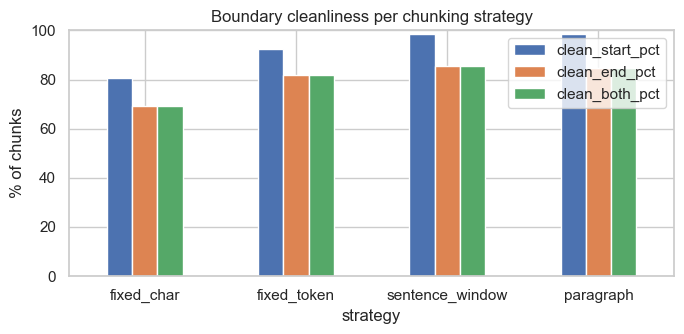

In [8]:
bq_out = CFG.processed_dir / "chunking_boundary_quality.csv"
bq_df.to_csv(bq_out, index=False)
print("saved ->", bq_out)

fig, ax = plt.subplots(figsize=(7, 3.5))
bq_df.plot(x="strategy", y=["clean_start_pct","clean_end_pct","clean_both_pct"], kind="bar", ax=ax)
ax.set_title("Boundary cleanliness per chunking strategy")
ax.set_ylabel("% of chunks"); ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(CFG.processed_dir / "chunking_boundary_quality.png", dpi=140)
plt.show()


## 4. Overlap / length heatmaps

Token-length distribution tells us whether a strategy respects the intended budget or produces a long tail (a common failure mode of paragraph chunking on noisy HTML).

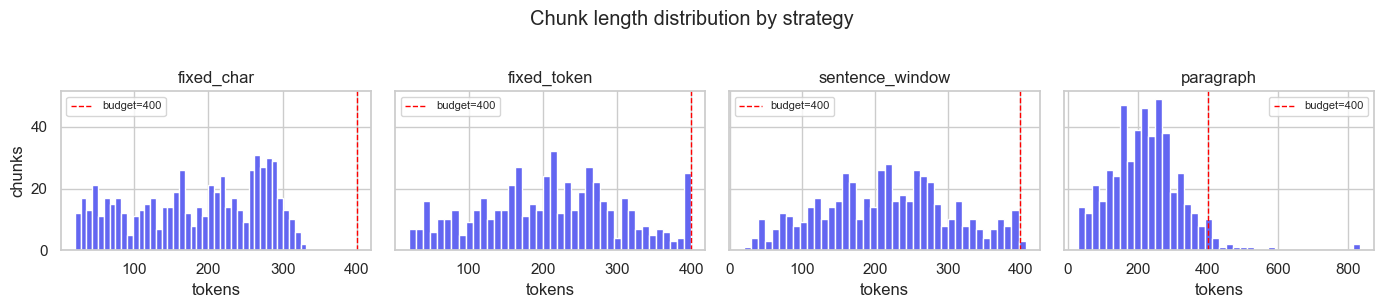

In [9]:
import itertools
fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(14, 3), sharey=True)
for ax, (name, fn) in zip(axes, STRATEGIES.items()):
    tok_lens = [len(c.split()) for t in sample_texts for c in fn(t)]
    ax.hist(tok_lens, bins=40, color="#6366f1", edgecolor="white")
    ax.axvline(CHUNK_SIZE_TOKENS, color="red", lw=1, ls="--", label=f"budget={CHUNK_SIZE_TOKENS}")
    ax.set_title(name); ax.set_xlabel("tokens")
    ax.legend(fontsize=8)
axes[0].set_ylabel("chunks")
fig.suptitle("Chunk length distribution by strategy", y=1.02)
fig.tight_layout()
fig.savefig(CFG.processed_dir / "chunking_length_heatmap.png", dpi=140)
plt.show()


## 5. Produce final `chunks.parquet`

Per the roadmap we commit to **sentence_window** @ 400 tokens / 50 overlap — it's the strategy with the highest `clean_both_pct` while respecting the budget. We generate `chunks.parquet` with deterministic `chunk_id` values so the BM25 / dense / rerank indexes downstream can join safely.

Schema:

| field | type | notes |
|-------|------|-------|
| `chunk_id`    | str | `{cord_uid}_c{idx:03d}` |
| `cord_uid`    | str | paper id (FK to papers_clean) |
| `chunk_index` | int | position within paper |
| `title`       | str | paper title, carried for display |
| `chunk_text`  | str | the text itself |
| `n_tokens`    | int | word count |
| `journal`    | int | word count |
| `publishtime`    | int | word count |
| `doi`    | int | word count |



In [10]:
def produce_chunks(papers, strategy="sentence_window"):
    fn = STRATEGIES[strategy]
    records = []
    for _, row in papers.iterrows():
        cid = str(row.get("cord_uid", "unknown"))
        title = (row.get("title") or "").strip()
        text = row["full_text"]
        for idx, chunk in enumerate(fn(text)):
            records.append({
                "chunk_id":    f"{cid}_c{idx:03d}",
                "cord_uid":    cid,
                "chunk_index": idx,
                "title":       title,
                "chunk_text":  chunk,
                "n_tokens":    len(chunk.split()),
                "journal":     (row.get("journal") or ""),
                "publish_time": (row.get("publish_time") or ""),
                "doi":         (row.get("doi") or ""),
            })
    return pd.DataFrame(records)

chunks = produce_chunks(papers, strategy="sentence_window")
print(f"built {len(chunks):,} chunks from {papers['cord_uid'].nunique():,} papers")
print("tokens per chunk  mean={:.0f}  median={:.0f}  p95={:.0f}".format(
    chunks["n_tokens"].mean(), chunks["n_tokens"].median(), chunks["n_tokens"].quantile(0.95)))

chunks_out = CFG.chunks_path
chunks.to_parquet(chunks_out, index=False)
print("saved ->", chunks_out)


built 1,034 chunks from 1,000 papers
tokens per chunk  mean=215  median=215  p95=371
saved -> D:\SciRet-Scientific-Information-Made-Easy\Sciret2\1_data\processed\tier1\chunks.parquet


In [11]:
# Append chunking info to tier manifest so Notebook 03+ can assert.
man = json.loads(CFG.tier_manifest_path.read_text())
man.update({
    "chunking": {
        "strategy": "sentence_window",
        "chunk_size_tokens": CHUNK_SIZE_TOKENS,
        "overlap_tokens_equiv_sentences": 2,
        "min_tokens": MIN_TOKENS_PER_CHUNK,
        "n_chunks": int(len(chunks)),
        "output": str(chunks_out),
    }
})
CFG.tier_manifest_path.write_text(json.dumps(man, indent=2))
print("manifest updated:", CFG.tier_manifest_path)


manifest updated: D:\SciRet-Scientific-Information-Made-Easy\Sciret2\1_data\processed\tier1\tier_manifest.json


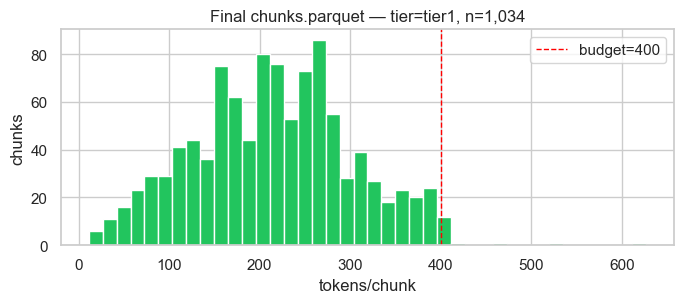

In [12]:
# One final visual sanity check: token-length histogram of the committed chunks.
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(chunks["n_tokens"], bins=40, color="#22c55e", edgecolor="white")
ax.axvline(CHUNK_SIZE_TOKENS, color="red", lw=1, ls="--", label=f"budget={CHUNK_SIZE_TOKENS}")
ax.set_title(f"Final chunks.parquet — tier={CFG.tier}, n={len(chunks):,}")
ax.set_xlabel("tokens/chunk"); ax.set_ylabel("chunks")
ax.legend()
fig.tight_layout()
fig.savefig(CFG.processed_dir / "final_chunks_length.png", dpi=140)
plt.show()


---
**Outputs produced**
* `1_data/processed/<tier>/chunks.parquet` — consumed by every downstream notebook
* `1_data/processed/<tier>/chunking_boundary_quality.{csv,png}` — strategy comparison
* `1_data/processed/<tier>/chunking_length_heatmap.png` — length distributions
* `1_data/processed/<tier>/final_chunks_length.png` — committed-strategy histogram

**Next:** Notebook 03 — BGE-M3 embeddings + ChromaDB index.


In [13]:
import pandas as pd
from pathlib import Path

chunks = pd.read_parquet(r"D:\SciRet-Scientific-Information-Made-Easy\Sciret2\1_data\processed\tier1\chunks.parquet")
print(chunks.columns.tolist())
print(chunks["journal"].notna().sum(), "non-null journals out of", len(chunks))
print(chunks["journal"].head(5))

['chunk_id', 'cord_uid', 'chunk_index', 'title', 'chunk_text', 'n_tokens', 'journal', 'publish_time', 'doi']
906 non-null journals out of 1034
0                      Index de Enfermería
1                         Pastoral Psychol
2    Current opinion in pulmonary medicine
3            Journal of perinatal medicine
4                                   Aksara
Name: journal, dtype: str
